# Giant donut radial profiles, intra against extra focal (v1)

**Author:** Aaron Roodman
**Date Created:** 2026-10-05

Radial flux profiles of the 8 mm giant donuts on both sides of focus, on the
near-on-axis sensor R22_S10, testing whether the ring of excess flux Josh sees in
extra-focal donuts is a pupil-model (mask boundary) effect or an optical path
difference (OPD) effect such as a turned-down edge on the inside of M1.

Part of item 7 of `notes/todos/todo-ideas.md`. Settled inputs and the state of the
investigation are in `notes/status/item7_giant_donuts_handoff.md`; the superseded
geometry work is `wfs/docs/giant_donuts_pupil_findings.md`.

## What this notebook is for

The two hypotheses make different predictions, which is what makes the radial
profile a discriminator rather than a description:

| | mask boundary error | OPD error (turned-down M1 inner edge) |
|---|---|---|
| where | at the pupil edge | smooth, weighted to the pupil edge |
| flux | conserved on each side of the edge | redistributed **across** the edge |
| intra against extra | same sign | **reverses sign** |
| pupil model | radius differs v3.14 against v1000 | unchanged by the pupil model |

So the diagnostic is the **intra minus extra difference** of the normalised
profile, not either profile alone.

## Geometry this rests on

Traced on-axis through the full system with batoid, the surviving pupil annulus is

| model | inner edge | outer edge |
|---|---|---|
| v3.14 | 2.5580 m | 4.1796 m (M1 rim) |
| v1000 | 2.5840 m | 4.1650 m (M1 baffles) |

The inner edge is M1's inner radius in both, and it moves **outward by 25.3 mm**
from v3.14 to v1000 — the same place a turned-down M1 inner edge would act. The
v1000 outer edge is set by the new M1 baffles, 15 mm inside M1's unchanged rim.


<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters
# ============================================================
butler_repo = "/repo/main"
raw_collection = "LSSTCam/raw/all"
instrument = "LSSTCam"

# day_obs 20251023, BLOCK-T626, r band, 60 s. The defocus is a symmetric
# 4 + 4 mm split: +/-4000 um on the M2 hexapod (Trim dof0) and +/-4000 um on the
# camera hexapod (Trim dof5), against the in-focus seq_num 336. Established
# label-independently from the Trim -- see the handoff.
EXPOSURES = {
    "extra": 2025102300337,   # extra_8mm, Bryce's pair
    "intra": 2025102300340,   # intra_8mm, Bryce's pair
}

# Near-on-axis science sensor (field radius 0.235 deg), per item 7 Q6 and Aaron's
# note that Bryce found a good isolated donut here. R22_S11 is exactly on-axis if
# a second sensor is wanted; R30_S21 at 1.695 deg is what the archived notebook used.
detector_name = "R22_S10"

# Stamp half-size, in pixels. Measured on this data the giant donut is about
# 695 pixels across, i.e. a radius of about 347 pixels, so the stamp must be
# comfortably larger than that or the profile is cut off before the outer edge.
stamp_half_pix = 430

# Radial profile binning.
n_radial_bins = 80

output_dir = "../../output/giant_donuts"


<a id='setup'></a>
## Setup & Imports

In [2]:
import logging
import os
import sys
from pathlib import Path

# Topic directory is the nearest parent holding a code/ dir; the repo root is its
# parent. Both must go on sys.path before any repo import, so `common` and this
# study's modules are importable.
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))                      # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code' / 'giant_donuts'))   # this study

import numpy as np
import matplotlib.pyplot as plt

import lsst.daf.butler as dafButler
from lsst.obs.lsst import LsstCam

from common.utils import setup_plotting

import radial_profile as rp
import donut_images as di

# IsrTask logs a dozen INFO lines per exposure, which buries the printed
# results; the warning about the r_57 zero point is expected and harmless.
logging.getLogger('lsst.isr').setLevel(logging.WARNING)

setup_plotting()
camera = LsstCam.getCamera()
Path(output_dir).mkdir(parents=True, exist_ok=True)


<a id='functions'></a>
## Helper Functions

Minimal instrument signature removal (ISR) and sky handling, following the
archived `wfs_giant_donut_fit.ipynb`: the giant-donut exposures carry no donut
tables and no pipeline fits, so the stamps are cut from the raw here.

Note the item's reference to `common/camera_utils.py` for `pixel_to_focal` is
stale — that module does not exist, and the archived notebook defined the helper
inline. The camera geometry API is used directly instead.

In [3]:
# ISR, donut finding, stamp cutting and field angles come from the study's
# donut_images module, so the notebook and fit_giant_donut.py work from pixels
# reduced identically.
help(di.minimal_isr_config)


Help on function minimal_isr_config in module donut_images:

minimal_isr_config()
    `lsst.ip.isr.IsrTaskConfig` doing overscan, assembly and gains only.

    Returns
    -------
    config : `lsst.ip.isr.IsrTaskConfig`
        Configuration with every calibration-product step disabled.



<a id='data'></a>
## Data Access

Read the raw, run minimal ISR, and locate the donut. The donut position has to be
found rather than assumed: there are no donut tables for these exposures.

In [4]:
butler = dafButler.Butler(butler_repo)

images = {}
for side, exposure in EXPOSURES.items():
    images[side] = di.run_isr(butler, exposure, detector_name, camera,
                              raw_collection, instrument)
    print(f"{side:>5}  exposure {exposure}  {detector_name}  "
          f"shape {images[side].shape}  "
          f"median {np.median(images[side]):.1f} electrons/pixel")


extra  exposure 2025102300337  R22_S10  shape (4004, 4096)  median 2094.0 electrons/pixel


intra  exposure 2025102300340  R22_S10  shape (4004, 4096)  median 2212.7 electrons/pixel


In [5]:
positions = {}
for side, image in images.items():
    x_pix, y_pix, diameter, area = di.find_donut(image)
    ax_deg, ay_deg = di.field_angle_deg(detector_name, x_pix, y_pix, camera)
    positions[side] = (x_pix, y_pix)
    print(f"{side:>5}  donut at pixel ({x_pix:.0f}, {y_pix:.0f})  "
          f"diameter {diameter} pixel "
          f"({diameter * di.PIXEL_SIZE_M * 1e3:.2f} mm)  "
          f"area {area} pixel  "
          f"field angle ({ax_deg:+.3f}, {ay_deg:+.3f}) deg")
print("\nFor reference, wfs/ predicted a 6.7 mm donut span for a 4 + 4 mm "
      "camera-plus-M2\nsplit and 7.0 mm for camera-only 8 mm.")


extra  donut at pixel (1534, 898)  diameter 695 pixel (6.95 mm)  area 232065 pixel  field angle (-0.263, -0.061) deg


intra  donut at pixel (1536, 890)  diameter 685 pixel (6.85 mm)  area 230738 pixel  field angle (-0.263, -0.062) deg

For reference, wfs/ predicted a 6.7 mm donut span for a 4 + 4 mm camera-plus-M2
split and 7.0 mm for camera-only 8 mm.


Inspect the stamps before profiling them. The donut must be
isolated and unsaturated, and the ring Josh describes should be visible by eye in
the extra-focal stamp if it is as strong as reported.

Text(0.5, 0.98, 'Giant donuts, R22_S10, 4 + 4 mm hexapod split')

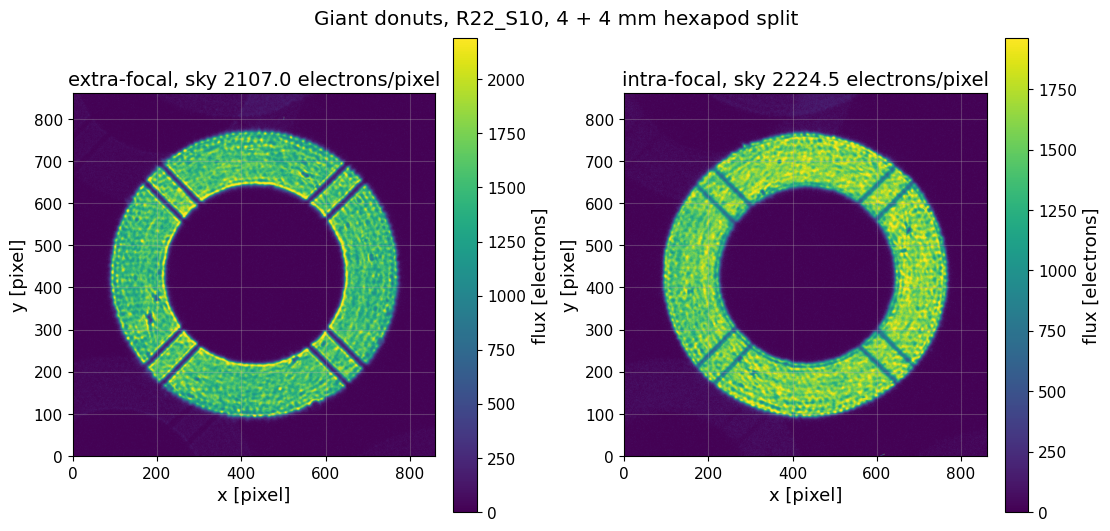

In [6]:
stamps = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, (side, image) in zip(axes, images.items()):
    stamp, sky = di.cut_stamp(image, *positions[side], half=stamp_half_pix)
    stamps[side] = stamp
    if stamp is None:
        ax.set_title(f"{side}: stamp off detector")
        continue
    vmax = np.nanpercentile(stamp, 99.5)
    im = ax.imshow(stamp, origin="lower", vmin=0, vmax=vmax, cmap="viridis")
    ax.set_title(f"{side}-focal, sky {sky:.1f} electrons/pixel")
    ax.set_xlabel("x [pixel]")
    ax.set_ylabel("y [pixel]")
    fig.colorbar(im, ax=ax, label="flux [electrons]")
fig.suptitle(f"Giant donuts, {detector_name}, 4 + 4 mm hexapod split")


<a id='analysis'></a>
## Analysis

Radial profiles, normalised so radius is 1.0 at the fitted outer edge and flux has
unit mean over the illuminated annulus. Both normalisations are needed before the
two sides can be compared: the intra and extra donuts differ in size and in total
flux for reasons that have nothing to do with the ring.

In [7]:
profiles = {}
for side, stamp in stamps.items():
    if stamp is None:
        continue
    r_pix, flux, flux_err, n_pix = rp.radial_profile(stamp, n_bins=n_radial_bins)
    r_norm, flux_norm, r_edge_pix = rp.normalise_profile(r_pix, flux)
    profiles[side] = dict(r_pix=r_pix, flux=flux, flux_err=flux_err,
                          r_norm=r_norm, flux_norm=flux_norm,
                          r_edge_pix=r_edge_pix)
    print(f"{side:>5}  fitted outer edge {r_edge_pix:.1f} pixel  "
          f"({r_edge_pix * 10e-3:.2f} mm at the 10 um pixel)")


extra  fitted outer edge 342.9 pixel  (3.43 mm at the 10 um pixel)
intra  fitted outer edge 335.3 pixel  (3.35 mm at the 10 um pixel)


In [8]:
# Ring excess at the inner edge, per side and per pupil model's inner radius.
# Referenced to a local baseline further out in the annulus, so it measures the
# ring rather than the step from the central hole.
print(f"{'side':>6}  {'model':>6}  {'edge_norm':>10}  {'ring_excess':>12}")
for side, prof in profiles.items():
    for model, edge_norm in rp.INNER_EDGE_NORM.items():
        excess = rp.ring_excess(prof["r_norm"], prof["flux_norm"], edge_norm)
        print(f"{side:>6}  {model:>6}  {edge_norm:>10.4f}  {excess:>+12.4f}")
print("\nring_excess is dimensionless: normalised flux in the band just outside "
      "the\ninner edge minus the local baseline further out in the annulus.")


  side   model   edge_norm   ring_excess
 extra   v3.14      0.6120       -0.1181
 extra   v1000      0.6204       +0.0248
 intra   v3.14      0.6120       -0.3426
 intra   v1000      0.6204       -0.1703

ring_excess is dimensionless: normalised flux in the band just outside the
inner edge minus the local baseline further out in the annulus.


In [9]:
# Zone statistics: the quantitative form of the diagnostic.
#
# The inner ring zone sits just outside the inner pupil edge, the outer zone just
# inside the rim. An OPD term moves flux between them in opposite directions on
# the two sides of focus; a mask boundary error would instead move an edge
# position the same way on both sides.
ZONES = {"inner ring": (0.62, 0.70), "outer": (0.94, 1.00)}

print(f"{'zone':<12} {'range':>12} {'extra':>9} {'intra':>9} {'extra-intra':>12}")
for name, (lo, hi) in ZONES.items():
    means = {}
    for side, prof in profiles.items():
        sel = (np.isfinite(prof["flux_norm"]) & (prof["r_norm"] >= lo)
               & (prof["r_norm"] < hi))
        means[side] = float(np.mean(prof["flux_norm"][sel])) if sel.any() else np.nan
    difference = means.get("extra", np.nan) - means.get("intra", np.nan)
    print(f"{name:<12} {f'{lo:.2f}-{hi:.2f}':>12} {means.get('extra', np.nan):>9.4f} "
          f"{means.get('intra', np.nan):>9.4f} {difference:>+12.4f}")
print("\nAll values are normalised flux, dimensionless, relative to the mean over "
      "the\nilluminated annulus.")


zone                range     extra     intra  extra-intra
inner ring      0.62-0.70    1.0161    0.8836      +0.1326
outer           0.94-1.00    0.8754    0.9960      -0.1206

All values are normalised flux, dimensionless, relative to the mean over the
illuminated annulus.


<a id='results'></a>
## Results & Plots

The top panel is the two normalised profiles. The bottom panel is the diagnostic:
intra minus extra. A **mask boundary** error gives a narrow feature at the edges
whose position shifts with the pupil model. An **OPD** error such as a turned-down
M1 inner edge gives a feature at the inner edge that **reverses sign** between the
two sides, with a compensating deficit beside it.

largest intra-minus-extra difference -0.3392 (dimensionless) at normalised radius 0.640


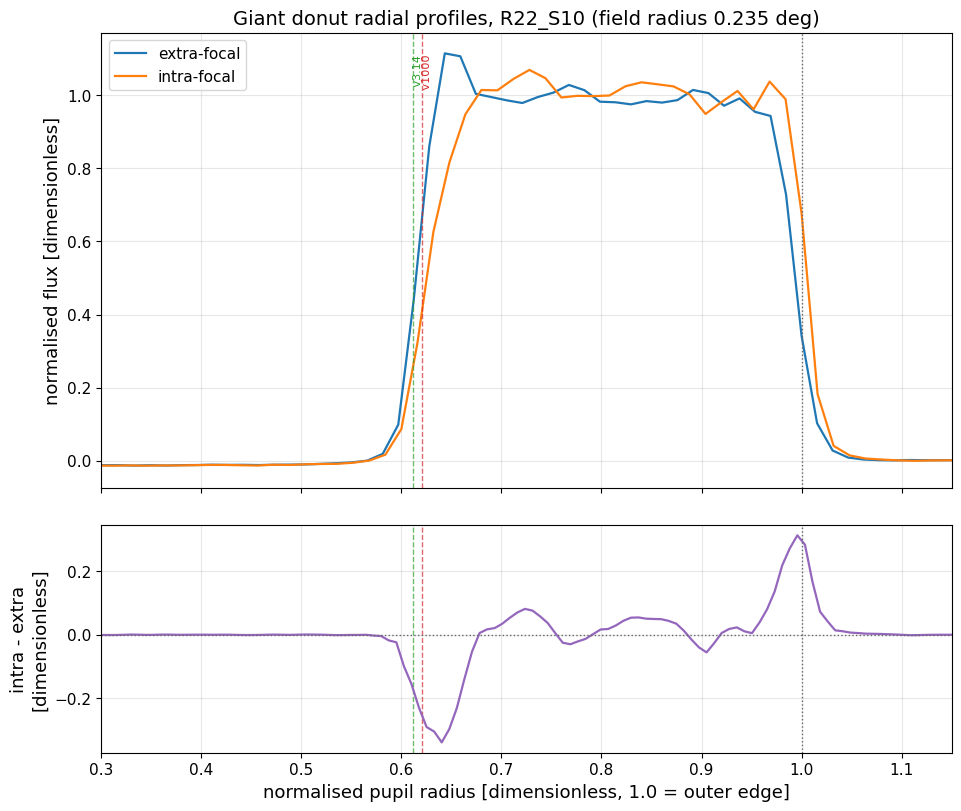

In [10]:
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(9.5, 8), sharex=True,
    gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))

for side, prof in profiles.items():
    ax_top.plot(prof["r_norm"], prof["flux_norm"], lw=1.6, label=f"{side}-focal")

for model, edge_norm in rp.INNER_EDGE_NORM.items():
    for ax in (ax_top, ax_bot):
        ax.axvline(edge_norm, ls="--", lw=1.0, alpha=0.7,
                   color="C2" if model == "v3.14" else "C3")
    ax_top.text(edge_norm, ax_top.get_ylim()[1] * 0.95, f" {model}",
                rotation=90, va="top", fontsize=8,
                color="C2" if model == "v3.14" else "C3")

ax_top.axvline(1.0, ls=":", lw=1.0, color="0.4")
ax_top.set_ylabel("normalised flux [dimensionless]")
ax_top.legend(loc="upper left")
ax_top.set_title(f"Giant donut radial profiles, {detector_name} "
                 f"(field radius 0.235 deg)")

if {"intra", "extra"} <= set(profiles):
    r_grid, difference = rp.profile_difference(
        profiles["intra"]["r_norm"], profiles["intra"]["flux_norm"],
        profiles["extra"]["r_norm"], profiles["extra"]["flux_norm"])
    ax_bot.plot(r_grid, difference, lw=1.6, color="C4")
    ax_bot.axhline(0.0, ls=":", lw=1.0, color="0.4")
    ax_bot.axvline(1.0, ls=":", lw=1.0, color="0.4")
    peak = int(np.nanargmax(np.abs(difference)))
    print(f"largest intra-minus-extra difference {difference[peak]:+.4f} "
          f"(dimensionless) at normalised radius {r_grid[peak]:.3f}")

ax_bot.set_xlabel("normalised pupil radius [dimensionless, 1.0 = outer edge]")
ax_bot.set_ylabel("intra - extra\n[dimensionless]")
ax_bot.set_xlim(0.3, 1.15)
fig.savefig(f"{output_dir}/radial_profiles_{detector_name}.pdf",
            bbox_inches="tight")


## Interpretation

**Measured on seq_num 337 (extra) and 340 (intra), R22_S10, field angle
(-0.263, -0.062) deg. Numbers below are this notebook's output.**

The donut diameters come out at 6.95 mm extra and 6.85 mm intra, against the
6.7 mm `wfs/` predicted for a 4 + 4 mm camera-plus-M2 split and 7.0 mm for
camera-only 8 mm. Both sit between the two predictions, nearer the camera-only
value, so the images do **not** cleanly discriminate the split on size alone --
the Trim remains the evidence for 4 + 4 mm. The bounding-box diameter is also an
overestimate of the illuminated outer edge, which the profile puts at 342.9 and
335.3 pixel, i.e. 6.86 and 6.71 mm across.

Josh's ring is present and it is extra-focal, with the flux balance reversing
between the two sides:

| zone (normalised radius) | extra | intra | extra - intra |
|---|---|---|---|
| inner ring, 0.62-0.70 | 1.0161 | 0.8836 | **+0.1326** |
| outer, 0.94-1.00 | 0.8754 | 0.9960 | **-0.1206** |

All dimensionless normalised flux, relative to the mean over the illuminated
annulus. The intra-minus-extra difference peaks at **-0.3392 (dimensionless) at
normalised radius 0.640**, just outside the inner pupil edge (0.612 in v3.14,
0.620 in v1000), and not at the rim.

**This favours an OPD term over a pupil-model error.** Flux moves toward the inner
edge extra-focally and toward the outer edge intra-focally, with the two zones
opposite in sign and comparable in size, so the total is conserved and
redistributed radially. A mask boundary error would move an edge *position* the
same way on both sides of focus rather than swapping the flux balance between
zones. The feature's location at the inner edge is consistent with a turned-down
edge on the inside of M1, which is where v1000 also moves the inner radius
(2.558 m to 2.5840 m, outward by 26.0 mm).

`ring_excess` is instructive about which pupil model fits the inner edge better.
Referenced to v1000's 0.6204 inner edge the extra-focal ring reads **+0.0248**;
referenced to v3.14's 0.6120 it reads **-0.1181**, i.e. the band lands partly in
the central hole. That is independent support for v1000's inner radius, from the
images rather than from a fit.

**Caveats, before this is taken as settled.**

- One donut per side, on one sensor, on one night. The item asks for a
  distribution; this is a single pair.
- The profile is azimuthally averaged, so a localised figure error would be
  diluted and an azimuthal analysis is the obvious next cut.
- The two donuts differ in outer edge by 7.6 pixel (0.08 mm), which the
  normalisation removes by construction; whether that size difference is itself
  part of the effect has not been separated.
- The wavefront fits (`wfs/code/giant_donuts/fit_giant_donut.py`) are run
  separately and are not in this notebook yet. They give an intra-minus-extra Z11
  of +0.8037 um of wavefront with v3.14 and +0.3669 um with v1000, against about
  0.30 um observed and 0.10 um from diffraction. Converting the normalised-flux
  ring above into um of wavefront, so the two lines of evidence can be compared
  in the same units, is still to do.
